In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

In [8]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

In [9]:
df1 = pd.read_csv("../data/file2.csv")
df1.head()

,id,deleted,deleted_by_cascade,created_at,updated_at,price,volume,total_volume,amount,rnn,status,is_send,temperature,pressure,branch_id,dispenser_id,shift_id,operator_id,filial_created_at,filial_updated_at,video_record_id,arm_price,density,car_id,district_id,fuel_type_violation,pressure_violation,region_id,technically_inspection,without_violations,tenant_id
0,109531,NaN,False,2025-05-13 01:26:08.107612+00:00,2025-05-13 01:26:08.219120+00:00,5200.0,24.035,3992802.829,124982.0,0,not_fiscally,False,23.5,219.0,1,6,81.0,2.0,2025-05-13 01:25:40.024000+00:00,2025-05-13 01:25:40.303822+00:00,90921.0,5200.0,NaN,2736.0,160,0,1,8,0,0,2
1,110196,NaN,False,2025-05-13 07:34:40.127294+00:00,2025-05-13 07:34:40.229165+00:00,5200.0,12.206,4391139.268,63471.2,0,not_fiscally,False,34.0,212.0,1,3,81.0,2.0,2025-05-13 07:34:16.208000+00:00,2025-05-13 07:34:16.522197+00:00,91545.0,5200.0,NaN,3842.0,160,0,1,8,0,0,2
2,110908,NaN,False,2025-05-13 13:41:12.049081+00:00,2025-05-13 13:41:12.156662+00:00,5200.0,15.213,3102512.332,79107.6,0,not_fiscally,False,34.0,204.0,1,1,81.0,2.0,2025-05-13 13:40:45.301000+00:00,2025-05-13 13:40:45.597329+00:00,92241.0,5200.0,NaN,23189.0,160,0,0,8,0,1,2
3,110496,NaN,False,2025-05-13 10:05:11.537951+00:00,2025-05-13 10:05:11.655476+00:00,5200.0,9.616,4809855.026,50000.0,0,not_fiscally,False,35.5,199.0,1,4,81.0,2.0,2025-05-13 10:04:42.810000+00:00,2025-05-13 10:04:43.123466+00:00,91835.0,5200.0,NaN,25100.0,160,0,0,8,0,1,2
4,110186,NaN,False,2025-05-13 07:29:40.069106+00:00,2025-05-13 07:29:40.184094+00:00,5200.0,7.693,3993922.662,40000.0,0,not_fiscally,False,32.5,199.0,1,6,81.0,2.0,2025-05-13 07:29:34.955000+00:00,2025-05-13 07:29:35.248391+00:00,91540.0,5200.0,NaN,5683.0,160,0,0,8,0,1,2


In [10]:
df1.tail()

,id,deleted,deleted_by_cascade,created_at,updated_at,price,volume,total_volume,amount,rnn,status,is_send,temperature,pressure,branch_id,dispenser_id,shift_id,operator_id,filial_created_at,filial_updated_at,video_record_id,arm_price,density,car_id,district_id,fuel_type_violation,pressure_violation,region_id,technically_inspection,without_violations,tenant_id
322022,316556,NaN,False,2025-09-08 17:00:01.824637+00:00,2025-09-08 17:00:02.088022+00:00,5200.0,11.539,4534228.221,60000.0,0,not_fiscally,False,28.5,219.0,1,2,182.0,2.0,2025-09-08 16:59:35.185000+00:00,2025-09-08 16:59:35.503521+00:00,287247.0,5200.0,NaN,35134.0,160,0,1,8,0,0,2
322023,316561,NaN,False,2025-09-08 17:04:35.059227+00:00,2025-09-08 17:04:35.246099+00:00,5200.0,9.386,4534237.607,48807.2,0,not_fiscally,False,28.5,221.0,1,2,182.0,2.0,2025-09-08 17:04:18.636000+00:00,2025-09-08 17:04:18.981776+00:00,287251.0,5200.0,NaN,2667.0,160,0,1,8,0,0,2
322024,316579,NaN,False,2025-09-08 18:28:01.931059+00:00,2025-09-08 18:28:02.080955+00:00,5200.0,0.000,266725.069,0.0,0,not_fiscally,False,28.0,1.0,1,7,183.0,2.0,2025-09-08 18:27:36.257000+00:00,2025-09-08 18:27:36.583856+00:00,NaN,5200.0,NaN,NaN,160,0,0,8,0,1,2
322025,316425,NaN,False,2025-09-08 15:28:02.365967+00:00,2025-09-08 15:28:02.652345+00:00,5200.0,13.888,5226417.652,72217.6,0,not_fiscally,False,32.0,219.0,1,4,182.0,2.0,2025-09-08 15:27:44.297000+00:00,2025-09-08 15:27:44.645260+00:00,287121.0,5200.0,NaN,1242.0,160,0,1,8,0,0,2
322026,316449,NaN,False,2025-09-08 15:44:01.675467+00:00,2025-09-08 15:44:01.892021+00:00,5200.0,12.886,4533990.012,67007.2,0,not_fiscally,False,31.5,223.0,1,2,182.0,2.0,2025-09-08 15:43:47.660000+00:00,2025-09-08 15:43:47.971990+00:00,NaN,5200.0,NaN,NaN,160,0,1,8,0,0,2


In [11]:
df1.shape

(322027, 31)

In [12]:
df1['filial_created_at'].nunique()


321886

In [13]:
df1['filial_updated_at'].nunique()

321677

In [14]:
df1[['created_at', 'filial_created_at', 'filial_updated_at']].head(10)

,created_at,filial_created_at,filial_updated_at
0,2025-05-13 01:26:08.107612+00:00,2025-05-13 01:25:40.024000+00:00,2025-05-13 01:25:40.303822+00:00
1,2025-05-13 07:34:40.127294+00:00,2025-05-13 07:34:16.208000+00:00,2025-05-13 07:34:16.522197+00:00
2,2025-05-13 13:41:12.049081+00:00,2025-05-13 13:40:45.301000+00:00,2025-05-13 13:40:45.597329+00:00
3,2025-05-13 10:05:11.537951+00:00,2025-05-13 10:04:42.810000+00:00,2025-05-13 10:04:43.123466+00:00
4,2025-05-13 07:29:40.069106+00:00,2025-05-13 07:29:34.955000+00:00,2025-05-13 07:29:35.248391+00:00
5,2025-05-13 12:57:11.988014+00:00,2025-05-13 12:57:00.283000+00:00,2025-05-13 12:57:00.598668+00:00
6,2025-05-13 03:08:38.850484+00:00,2025-05-13 03:08:22.701000+00:00,2025-05-13 03:08:22.998715+00:00
7,2025-05-13 15:58:12.245521+00:00,2025-05-13 15:57:41.291000+00:00,2025-05-13 15:57:41.601439+00:00
8,2025-05-13 11:05:41.748721+00:00,2025-05-13 11:05:18.748000+00:00,2025-05-13 11:05:19.059515+00:00
9,2025-05-13 12:06:41.773223+00:00,2025-05-13 12:06:18.980000+00:00,2025-05-13 12:06:19.258161+00:00


In [15]:
df1.isnull().sum()

id                             0
deleted                   322027
deleted_by_cascade             0
created_at                     0
updated_at                     0
price                          0
volume                         0
total_volume                   0
amount                         0
rnn                            0
status                         0
is_send                        0
temperature                    0
pressure                       0
branch_id                      0
dispenser_id                   0
shift_id                       3
operator_id                    1
filial_created_at              0
filial_updated_at              0
video_record_id            39816
arm_price                      0
density                   321685
car_id                     39816
district_id                    0
fuel_type_violation            0
pressure_violation             0
region_id                      0
technically_inspection         0
without_violations             0
tenant_id 

In [16]:
df1.describe()

,id,deleted,price,volume,total_volume,amount,rnn,temperature,pressure,branch_id,dispenser_id,shift_id,operator_id,video_record_id,arm_price,density,car_id,district_id,fuel_type_violation,pressure_violation,region_id,technically_inspection,without_violations,tenant_id
count,322027.000000,0.0,322027.000000,322027.000000,3.220270e+05,322027.000000,322027.0,322027.000000,322027.000000,322027.0,322027.000000,322024.000000,322026.0,282211.000000,322027.000000,342.0,282211.000000,322027.0,322027.000000,322027.000000,322027.0,322027.000000,322027.000000,322027.0
mean,161180.604005,NaN,4875.560434,12.144032,3.931626e+06,58899.007945,0.0,29.074894,208.036660,1.0,4.003888,105.973890,2.0,145550.876925,4346.587087,0.7,13949.836668,160.0,0.029889,0.630761,8.0,0.131669,0.311014,2.0
std,92899.225965,NaN,525.857540,5.397381,1.191972e+06,25811.701122,0.0,6.439995,14.862419,0.0,1.964374,48.420623,0.0,84172.289794,1750.630511,0.0,12450.067126,0.0,0.170281,0.482600,0.0,0.338131,0.462909,0.0
min,1.000000,NaN,3950.000000,0.000000,0.000000e+00,0.000000,0.0,0.000000,0.000000,1.0,1.000000,8.000000,2.0,12.000000,0.000000,0.7,2.000000,160.0,0.000000,0.000000,8.0,0.000000,0.000000,2.0
25%,80714.500000,NaN,4100.000000,9.616000,3.941403e+06,45869.200000,0.0,25.500000,202.000000,1.0,2.000000,64.000000,2.0,72844.500000,4100.000000,0.7,3651.000000,160.0,0.000000,0.000000,8.0,0.000000,0.000000,2.0
50%,161244.000000,NaN,5200.000000,11.539000,4.279785e+06,54756.000000,0.0,30.000000,210.000000,1.0,4.000000,107.000000,2.0,145227.000000,5200.000000,0.7,9865.000000,160.0,0.000000,1.000000,8.0,0.000000,0.000000,2.0
75%,241774.500000,NaN,5200.000000,14.201000,4.583615e+06,70000.000000,0.0,34.000000,216.000000,1.0,5.000000,150.000000,2.0,218274.500000,5200.000000,0.7,21561.000000,160.0,0.000000,1.000000,8.0,0.000000,1.000000,2.0
max,321954.000000,NaN,5200.000000,263.185000,5.237850e+06,980000.000000,0.0,43.000000,279.000000,1.0,10.000000,185.000000,2.0,292789.000000,5200.000000,0.7,49717.000000,160.0,1.000000,1.000000,8.0,1.000000,1.000000,2.0


In [17]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 322027 entries, 0 to 322026
Data columns (total 31 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      322027 non-null  int64  
 1   deleted                 0 non-null       float64
 2   deleted_by_cascade      322027 non-null  bool   
 3   created_at              322027 non-null  object 
 4   updated_at              322027 non-null  object 
 5   price                   322027 non-null  float64
 6   volume                  322027 non-null  float64
 7   total_volume            322027 non-null  float64
 8   amount                  322027 non-null  float64
 9   rnn                     322027 non-null  int64  
 10  status                  322027 non-null  object 
 11  is_send                 322027 non-null  bool   
 12  temperature             322027 non-null  float64
 13  pressure                322027 non-null  float64
 14  branch_id           

In [18]:
df1.nunique()

id                        321689
deleted                        0
deleted_by_cascade             1
created_at                322027
updated_at                322027
price                          3
volume                     21077
total_volume              319325
amount                     43777
rnn                            1
status                         1
is_send                        1
temperature                   84
pressure                     464
branch_id                      1
dispenser_id                  10
shift_id                     168
operator_id                    1
filial_created_at         321886
filial_updated_at         321677
video_record_id           281894
arm_price                      3
density                        1
car_id                     46685
district_id                    1
fuel_type_violation            2
pressure_violation             2
region_id                      1
technically_inspection         2
without_violations             2
tenant_id 

In [19]:
new_df1 = df1[["id", "created_at", "filial_created_at", "price", "volume",
               "amount", "dispenser_id", "operator_id",
               "car_id", "temperature", "density", "branch_id",
               "shift_id", "arm_price"]].copy()

In [20]:
new_df1.head()

,id,created_at,filial_created_at,price,volume,amount,dispenser_id,operator_id,car_id,temperature,density,branch_id,shift_id,arm_price
0,109531,2025-05-13 01:26:08.107612+00:00,2025-05-13 01:25:40.024000+00:00,5200.0,24.035,124982.0,6,2.0,2736.0,23.5,NaN,1,81.0,5200.0
1,110196,2025-05-13 07:34:40.127294+00:00,2025-05-13 07:34:16.208000+00:00,5200.0,12.206,63471.2,3,2.0,3842.0,34.0,NaN,1,81.0,5200.0
2,110908,2025-05-13 13:41:12.049081+00:00,2025-05-13 13:40:45.301000+00:00,5200.0,15.213,79107.6,1,2.0,23189.0,34.0,NaN,1,81.0,5200.0
3,110496,2025-05-13 10:05:11.537951+00:00,2025-05-13 10:04:42.810000+00:00,5200.0,9.616,50000.0,4,2.0,25100.0,35.5,NaN,1,81.0,5200.0
4,110186,2025-05-13 07:29:40.069106+00:00,2025-05-13 07:29:34.955000+00:00,5200.0,7.693,40000.0,6,2.0,5683.0,32.5,NaN,1,81.0,5200.0


In [21]:
new_df1.shape

(322027, 14)

In [22]:
new_df1.isnull().sum()

id                        0
created_at                0
filial_created_at         0
price                     0
volume                    0
amount                    0
dispenser_id              0
operator_id               1
car_id                39816
temperature               0
density              321685
branch_id                 0
shift_id                  3
arm_price                 0
dtype: int64

In [23]:
new_df1.duplicated().sum()

np.int64(0)

In [24]:
new_df1.nunique()

id                   321689
created_at           322027
filial_created_at    321886
price                     3
volume                21077
amount                43777
dispenser_id             10
operator_id               1
car_id                46685
temperature              84
density                   1
branch_id                 1
shift_id                168
arm_price                 3
dtype: int64

In [25]:
new_df1["filial_created_at"] = pd.to_datetime(new_df1["filial_created_at"], format='mixed')

In [26]:
new_df1["created_at"] = pd.to_datetime(new_df1["created_at"], format='mixed')

In [27]:
new_df1["filial_created_at"].dtype

datetime64[ns, UTC]

In [28]:
new_df1["created_at"].dtype

datetime64[ns, UTC]

In [29]:
farq_soat = (new_df1['created_at'] - new_df1['filial_created_at']).dt.total_seconds() / 3600
print(farq_soat.describe())
print(farq_soat.round().value_counts().head(20))

count    322027.000000
mean          5.669132
std          24.838687
min           0.000087
25%           0.002789
50%           0.005123
75%           0.007438
max         203.425167
dtype: float64
0.0     289457
1.0       1630
2.0       1287
3.0       1131
5.0        805
4.0        704
6.0        659
11.0       565
7.0        557
12.0       540
8.0        540
9.0        528
13.0       512
25.0       510
10.0       502
26.0       478
24.0       443
14.0       438
27.0       400
53.0       369
Name: count, dtype: int64


In [30]:
new_df1['local_time'] = new_df1['filial_created_at'] + pd.Timedelta(hours=5)

In [31]:
new_df1['local_time'].dt.floor('s').value_counts().sort_values(ascending=False).head(20)

local_time
2025-03-11 15:24:32+00:00    5
2025-09-06 07:19:06+00:00    5
2025-07-05 15:47:49+00:00    5
2025-09-05 10:25:41+00:00    5
2025-02-20 14:22:23+00:00    5
2025-02-15 10:10:21+00:00    5
2025-09-05 12:28:05+00:00    5
2025-09-05 10:46:23+00:00    5
2025-02-15 12:55:20+00:00    5
2025-09-05 12:54:34+00:00    5
2025-02-15 14:45:01+00:00    5
2025-09-05 10:10:42+00:00    5
2025-02-20 10:54:51+00:00    4
2025-09-05 12:34:13+00:00    4
2025-05-04 15:37:40+00:00    4
2025-09-05 08:33:14+00:00    4
2025-03-23 07:38:34+00:00    4
2025-09-06 08:19:57+00:00    4
2025-07-18 10:24:42+00:00    4
2025-05-27 11:42:05+00:00    4
Name: count, dtype: int64

In [32]:
new_df1["hour"] = new_df1["local_time"].dt.hour

In [33]:
new_df1[['local_time', 'hour']].head()

,local_time,hour
0,2025-05-13 06:25:40.024000+00:00,6
1,2025-05-13 12:34:16.208000+00:00,12
2,2025-05-13 18:40:45.301000+00:00,18
3,2025-05-13 15:04:42.810000+00:00,15
4,2025-05-13 12:29:34.955000+00:00,12


In [34]:
new_df1["day_of_week"] = new_df1["local_time"].dt.day_name()

In [35]:
new_df1[['local_time', 'hour', 'day_of_week']].head()

,local_time,hour,day_of_week
0,2025-05-13 06:25:40.024000+00:00,6,Tuesday
1,2025-05-13 12:34:16.208000+00:00,12,Tuesday
2,2025-05-13 18:40:45.301000+00:00,18,Tuesday
3,2025-05-13 15:04:42.810000+00:00,15,Tuesday
4,2025-05-13 12:29:34.955000+00:00,12,Tuesday


In [36]:
new_df1['month'] = new_df1['local_time'].dt.month_name()

In [37]:
new_df1[['local_time', 'hour', 'day_of_week', 'month']].head()

,local_time,hour,day_of_week,month
0,2025-05-13 06:25:40.024000+00:00,6,Tuesday,May
1,2025-05-13 12:34:16.208000+00:00,12,Tuesday,May
2,2025-05-13 18:40:45.301000+00:00,18,Tuesday,May
3,2025-05-13 15:04:42.810000+00:00,15,Tuesday,May
4,2025-05-13 12:29:34.955000+00:00,12,Tuesday,May


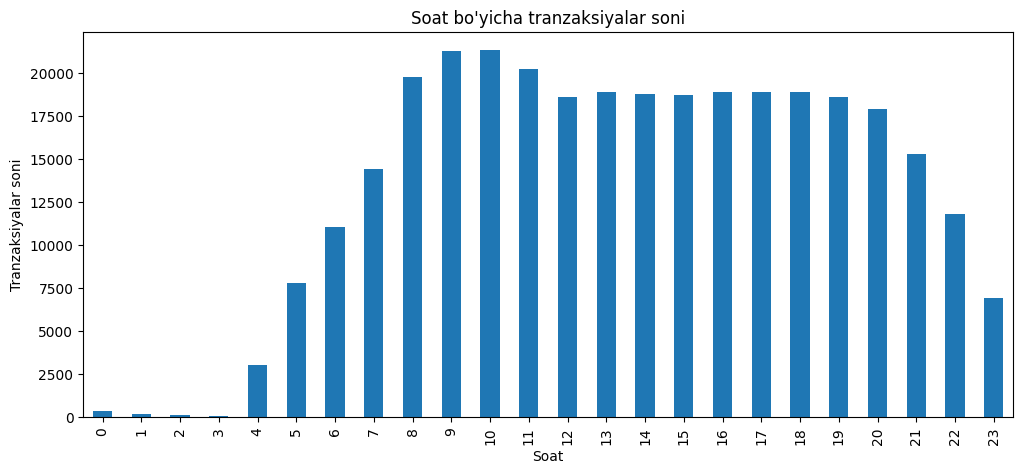

In [38]:
hourly = new_df1.groupby('hour').agg(
    tranzaksiyalar_soni=('id', 'count'),
    umumiy_hajm=('volume', 'sum')
)

hourly['tranzaksiyalar_soni'].plot( kind='bar', figsize=(12,5), title='Soat bo\'yicha tranzaksiyalar soni')
plt.xlabel('Soat')
plt.ylabel('Tranzaksiyalar soni')
plt.show()

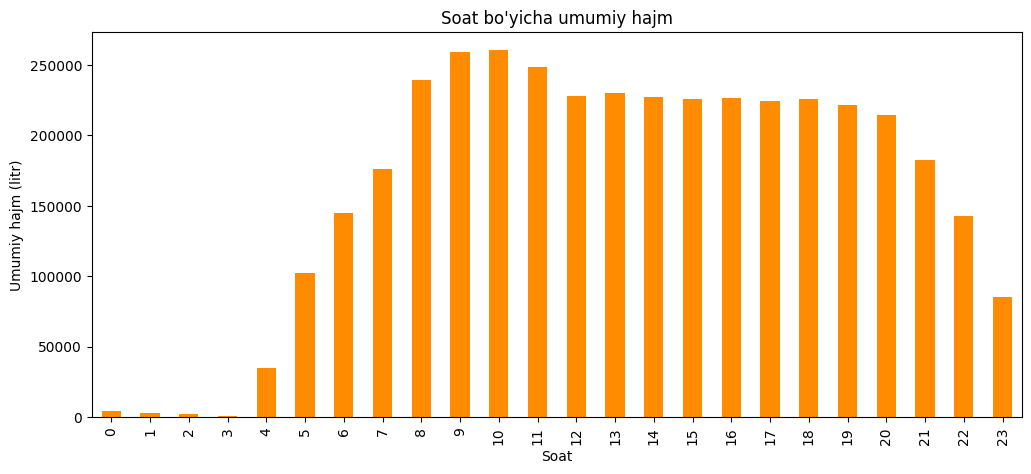

In [39]:
hourly['umumiy_hajm'].plot( kind='bar', figsize=(12,5), title='Soat bo\'yicha umumiy hajm', color='darkorange')
plt.xlabel('Soat')
plt.ylabel('Umumiy hajm (litr)')
plt.show()

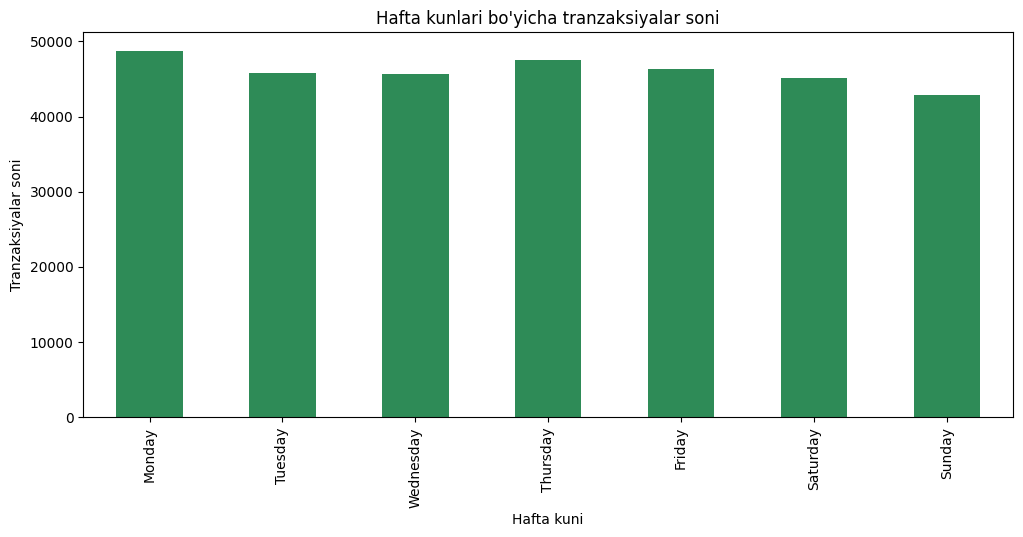

In [40]:
weekly = new_df1.groupby('day_of_week').agg(
    tranzaksiyalar_soni=('id', 'count'),
    umumiy_hajm=('volume', 'sum')
)

kun_tartibi = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekly = weekly.reindex(kun_tartibi)


weekly['tranzaksiyalar_soni'].plot( kind='bar', figsize=(12,5), title='Hafta kunlari bo\'yicha tranzaksiyalar soni', color='seagreen')
plt.xlabel('Hafta kuni')
plt.ylabel('Tranzaksiyalar soni')
plt.show()

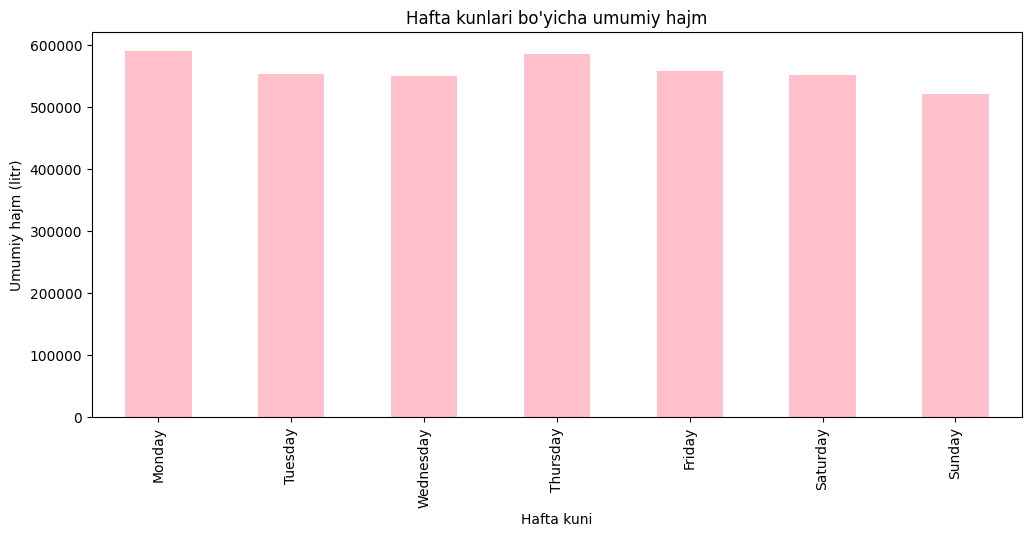

In [41]:
weekly['umumiy_hajm'].plot(kind='bar', figsize=(12,5), color='pink', title='Hafta kunlari bo\'yicha umumiy hajm')
plt.xlabel('Hafta kuni')
plt.ylabel('Umumiy hajm (litr)')
plt.show()

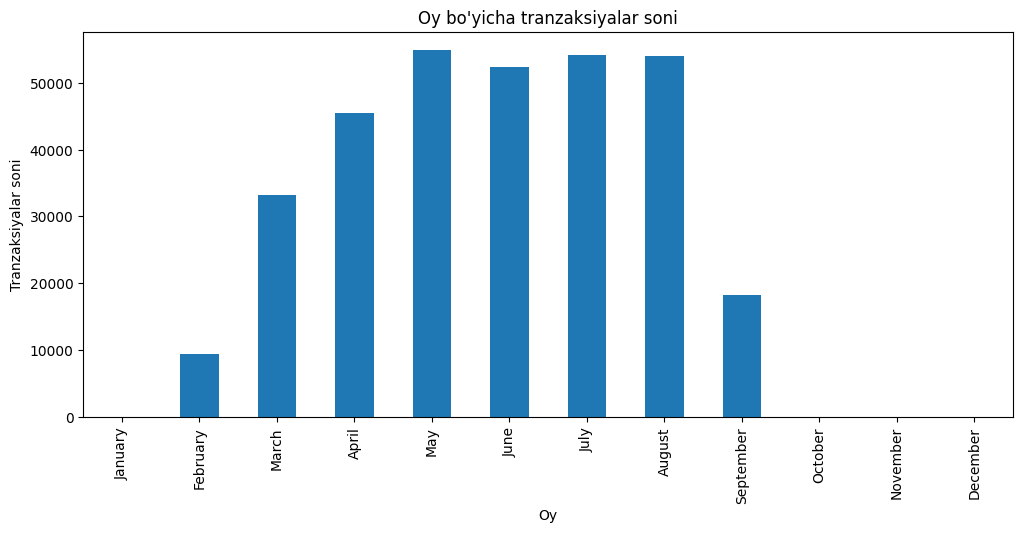

In [42]:
monthly = new_df1.groupby('month').agg(
    tranzaksiyalar_soni=('id', 'count'),
    umumiy_hajm=('volume', 'sum')
)
oy_tartibi = ['January', 'February', 'March', 'April', 'May', 'June', 
              'July', 'August', 'September', 'October', 'November', 'December']
monthly = monthly.reindex(oy_tartibi)

monthly['tranzaksiyalar_soni'].plot( kind='bar', figsize=(12,5), title='Oy bo\'yicha tranzaksiyalar soni')
plt.xlabel('Oy')
plt.ylabel('Tranzaksiyalar soni')
plt.show()

In [43]:
monthly

,tranzaksiyalar_soni,umumiy_hajm
month,,
January,NaN,NaN
February,9467.0,125112.859
March,33290.0,440019.379
April,45493.0,582854.007
May,54870.0,655699.004
June,52323.0,617310.543
July,54210.0,630033.884
August,54068.0,638599.326
September,18306.0,221077.098


In [44]:
new_df1.groupby('month')['local_time'].apply(lambda x: x.dt.date.nunique())

month
April        30
August       31
February     18
July         31
June         30
March        29
May          31
September    12
Name: local_time, dtype: int64

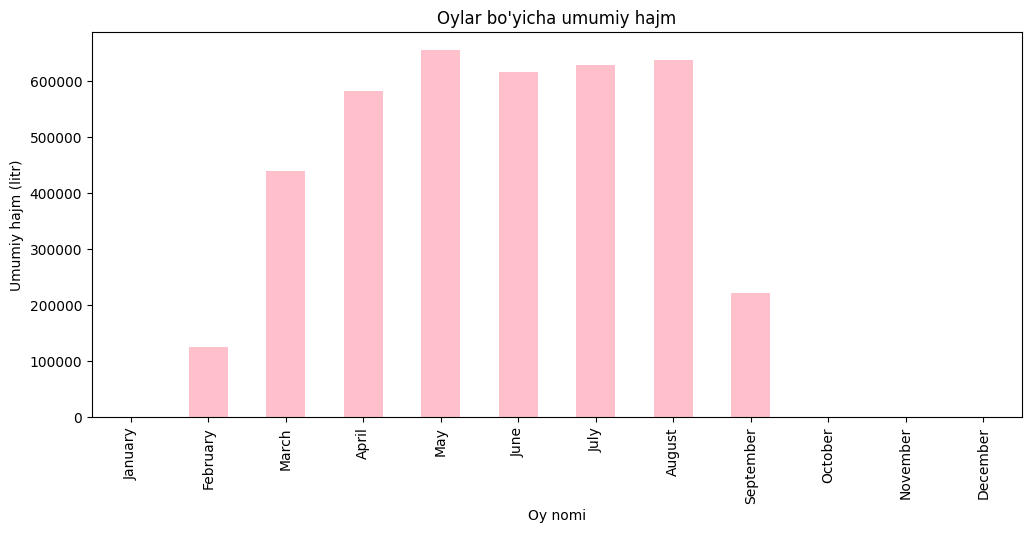

In [45]:
monthly['umumiy_hajm'].plot(kind='bar', figsize=(12,5), color='pink', title='Oylar bo\'yicha umumiy hajm')
plt.xlabel('Oy nomi')
plt.ylabel('Umumiy hajm (litr)')
plt.show()

## Xulosa: Band/bo'sh vaqtlar tahlili

**Soat bo'yicha:**

Eng band vaqt: ertalab soat 07:00-09:00 oralig'i (peak hour 08:00da, 13547 tranzaksiya)

Eng bo'sh vaqt: kechasi 00:00-04:00 oralig'i (eng kam soat 00:00da, 2895 tranzaksiya)

**Hafta kuni bo'yicha:**

Eng band kun: Seshanba (~49000 tranzaksiya)

Eng bo'sh kun: Yakshanba (~19000 tranzaksiya)

**Oy bo'yicha:**

Eng kop tranzaksiyalar bolgan oy: Iyul ( 41274ta)

Eng kam tranzaksiyalar bolgan oy: May ( 27995 ta, Aprel va Sentyabr oylari toliq berilmagani uchun May oyi tanlandi)


In [46]:
dispenser_stats = new_df1.groupby('dispenser_id').agg(
    tranzaksiyalar_soni=('id', 'count'),
    umumiy_hajm=('volume', 'sum')
)
dispenser_stats

,tranzaksiyalar_soni,umumiy_hajm
dispenser_id,,
1,35179,427701.282
2,49947,607156.681
3,53484,643668.314
4,54399,657198.688
5,49779,602286.073
6,45526,555050.993
7,19426,238542.940
8,11500,142918.368
9,1664,21226.224


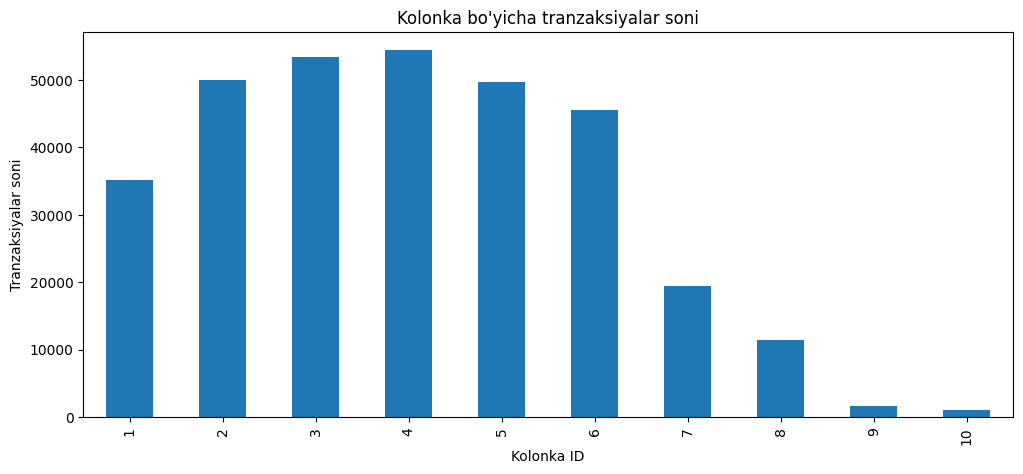

In [47]:
dispenser_stats['tranzaksiyalar_soni'].plot( kind='bar', figsize=(12,5), title='Kolonka bo\'yicha tranzaksiyalar soni')
plt.xlabel('Kolonka ID')
plt.ylabel('Tranzaksiyalar soni')
plt.show()

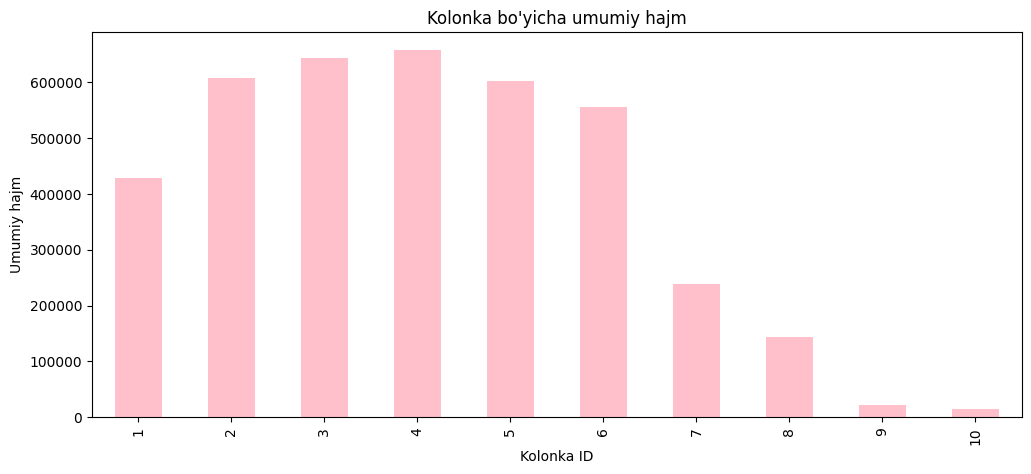

In [48]:
dispenser_stats['umumiy_hajm'].plot(kind='bar', figsize=(12,5), color='pink', title='Kolonka bo\'yicha umumiy hajm')
plt.xlabel('Kolonka ID')
plt.ylabel('Umumiy hajm')
plt.show()

In [49]:
new_df1[new_df1["dispenser_id"] == 13]["local_time"].agg(["min", "max"])

min   NaT
max   NaT
Name: local_time, dtype: datetime64[ns]

In [50]:
new_df1[new_df1["dispenser_id"] == 14]["local_time"].agg(["min", "max"])

min   NaT
max   NaT
Name: local_time, dtype: datetime64[ns]

In [51]:
new_df1[new_df1["dispenser_id"] == 7]["local_time"].agg(["min", "max"])

min   2025-02-11 16:15:44.468000+00:00
max   2025-09-12 11:39:24.810000+00:00
Name: local_time, dtype: datetime64[ns, UTC]

## Note: **dispenser_id**
Barcha 14 ta kolonka taxminan bir xil davr (5+ oy) davomida ishlagan bo'lsada, kolonka 13 va 14 boshqalariga qaraganda 100+ marta kamroq tranzaksiyaga ega (140 va 1929 ta, boshqalarida 6000-38000 ta). 
Bu farq ishlash muddati bilan bog'liq emas, shuning uchun sababi texnik nosozlik, joylashuv yoki maxsus foydalanish bo'lishi mumkin.

In [52]:
new_df1['hisoblangan_amount'] = new_df1['price'] * new_df1['volume']
farq = new_df1['amount'] - new_df1['hisoblangan_amount']
farq.describe()

count    3.220270e+05
mean    -4.427177e+00
std      1.762193e+03
min     -1.000000e+06
25%     -3.200000e+00
50%     -5.000000e-02
75%      0.000000e+00
max      5.820766e-11
dtype: float64

In [53]:
new_df1.loc[farq.idxmin()]

id                                                1248
created_at            2025-02-16 01:56:11.623761+00:00
filial_created_at     2025-02-16 01:56:08.672000+00:00
price                                           3950.0
volume                                         263.185
amount                                         39580.7
dispenser_id                                         5
operator_id                                        2.0
car_id                                             NaN
temperature                                        7.0
density                                            NaN
branch_id                                            1
shift_id                                          19.0
arm_price                                          0.0
local_time            2025-02-16 06:56:08.672000+00:00
hour                                                 6
day_of_week                                     Sunday
month                                         February
hisoblanga

In [54]:
new_df1[farq.abs() > 1000].shape

(1, 19)

In [55]:
print(7 / len(new_df1) * 100, "%")

0.0021737307741276353 %


In [56]:
new_df1[farq.abs() > 1000][['id', 'filial_created_at', 'price', 'volume', 'amount', 'hisoblangan_amount']]

,id,filial_created_at,price,volume,amount,hisoblangan_amount
178626,1248,2025-02-16 01:56:08.672000+00:00,3950.0,263.185,39580.7,1039580.75


In [57]:
new_df1[new_df1["volume"] <= 0].shape

(1108, 19)

In [58]:
new_df1["volume"].shape

(322027,)

In [59]:
new_df1[new_df1["amount"] <= 0].shape

(1108, 19)

In [60]:
new_df1[new_df1['volume'] <= 0]['volume'].value_counts().head(10)

volume
0.0    1108
Name: count, dtype: int64

In [61]:
new_df1[new_df1['volume'] == 0]['dispenser_id'].value_counts()

dispenser_id
5     189
2     154
7     138
6     136
3     132
4     123
1     115
8      74
9      24
10     23
Name: count, dtype: int64

In [62]:
new_df1[new_df1['volume'] == 0]['dispenser_id'].value_counts()

dispenser_id
5     189
2     154
7     138
6     136
3     132
4     123
1     115
8      74
9      24
10     23
Name: count, dtype: int64

In [63]:
new_df1_clean = new_df1[(new_df1['volume'] > 0) & (farq.abs() <= 1000)].copy()

In [64]:
print("Asl qatorlar soni:", len(new_df1))
print("Tozalangandan keyin:", len(new_df1_clean))
print("Chiqarib tashlangan:", len(new_df1) - len(new_df1_clean))

Asl qatorlar soni: 322027
Tozalangandan keyin: 320918
Chiqarib tashlangan: 1109


In [65]:
new_df1_clean.nlargest(10, 'volume')[['id', 'dispenser_id', 'volume', 'amount']]

,id,dispenser_id,volume,amount
178775,1246,6,246.302,972892.9
178534,1283,8,234.428,925990.6
178464,1257,10,215.205,850059.7
151760,2485,5,212.342,838750.9
173238,2883,8,205.421,811412.9
178579,1250,2,202.628,800380.6
178829,1253,3,198.156,782716.2
317479,312345,9,188.462,980000.0
54078,140626,2,173.077,900000.0
317081,312226,10,173.077,900000.0


In [66]:
new_df1_clean[new_df1_clean['volume'] <= 0].shape
new_df1_clean[new_df1_clean['amount'] <= 0].shape

(0, 19)

In [67]:
new_df1_clean['hisoblangan_amount_v2'] = new_df1_clean['price'] * new_df1_clean['volume']
farq_v2 = new_df1_clean['amount'] - new_df1_clean['hisoblangan_amount_v2']
farq_v2.describe()

count    3.209180e+05
mean    -1.326415e+00
std      1.583654e+00
min     -4.800000e+00
25%     -3.200000e+00
50%     -5.000000e-02
75%      0.000000e+00
max      5.820766e-11
dtype: float64

In [68]:
new_df1_clean.columns.to_list()

['id',
 'created_at',
 'filial_created_at',
 'price',
 'volume',
 'amount',
 'dispenser_id',
 'operator_id',
 'car_id',
 'temperature',
 'density',
 'branch_id',
 'shift_id',
 'arm_price',
 'local_time',
 'hour',
 'day_of_week',
 'month',
 'hisoblangan_amount',
 'hisoblangan_amount_v2']

In [69]:
kerakli_ustunlar = ['local_time','hour', 'day_of_week', 'month', 'dispenser_id', 'price', 'volume', 'amount', 'branch_id']
df = new_df1_clean[kerakli_ustunlar].copy()

In [70]:
df = df.sort_values(['dispenser_id', 'local_time'])
df['xizmat_vaqti'] = df.groupby('dispenser_id')['local_time'].diff().dt.total_seconds() / 60

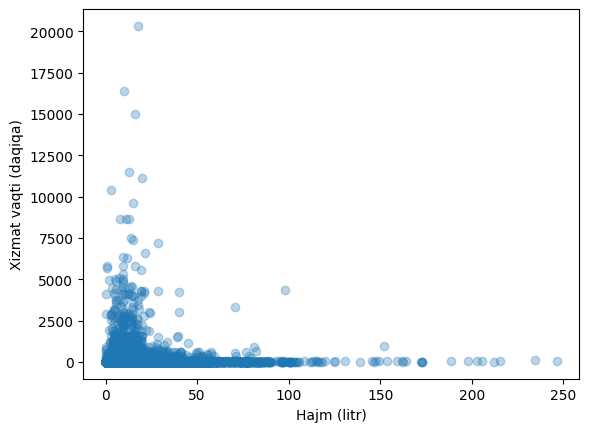

In [71]:
plt.scatter(df['volume'], df['xizmat_vaqti'], alpha=0.3)
plt.xlabel('Hajm (litr)')
plt.ylabel('Xizmat vaqti (daqiqa)')
plt.show()

In [72]:
df = df[df['xizmat_vaqti'] < 30]

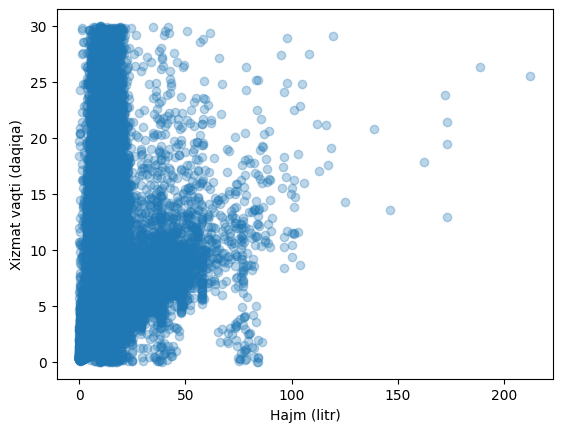

In [73]:
plt.scatter(df['volume'], df['xizmat_vaqti'], alpha=0.3)
plt.xlabel('Hajm (litr)')
plt.ylabel('Xizmat vaqti (daqiqa)')
plt.show()

In [74]:
filtered_df = df.copy()

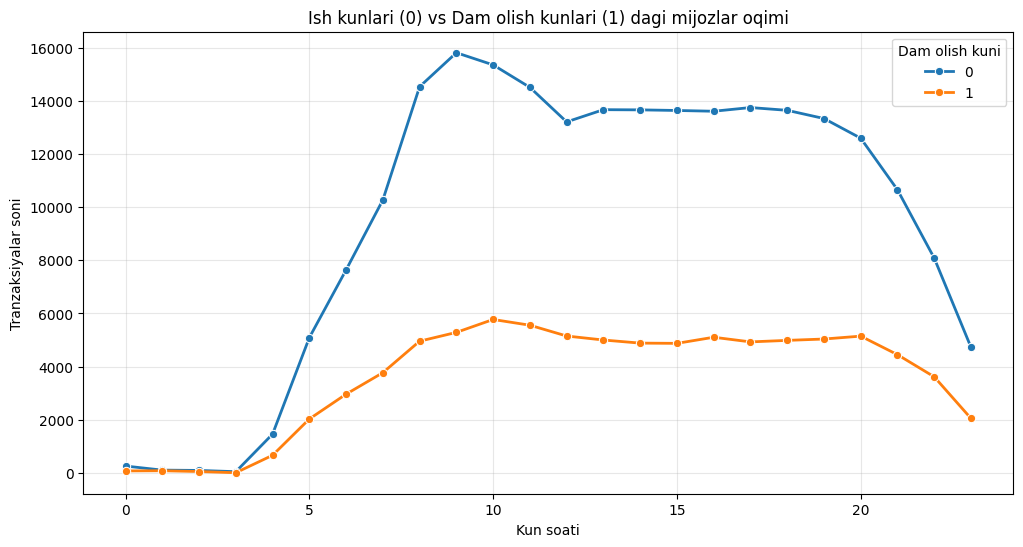

In [75]:
filtered_df['is_weekend'] = filtered_df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

hourly_weekend = filtered_df.groupby(['is_weekend', 'hour'])['volume'].count().reset_index()


plt.figure(figsize=(12, 6))
sns.lineplot(data=hourly_weekend, x='hour', y='volume', hue='is_weekend', marker='o', linewidth=2)
plt.title('Ish kunlari (0) vs Dam olish kunlari (1) dagi mijozlar oqimi')
plt.xlabel('Kun soati')
plt.ylabel('Tranzaksiyalar soni')
plt.grid(True, alpha=0.3)
plt.legend(title='Dam olish kuni')
plt.show()

In [76]:
filtered_df["vaqt_intervali"] = filtered_df["local_time"].dt.floor("30min").dt.time 

In [77]:
filtered_df

,local_time,hour,day_of_week,month,dispenser_id,price,volume,amount,branch_id,xizmat_vaqti,is_weekend,vaqt_intervali
178954,2025-02-14 15:29:51.496000+00:00,15,Friday,February,1,3950.0,14.719,58140.0,1,4.323017,0,15:00:00
178866,2025-02-14 15:41:49.214000+00:00,15,Friday,February,1,3950.0,21.782,86038.9,1,11.961967,0,15:30:00
178878,2025-02-15 04:44:04.494000+00:00,4,Saturday,February,1,3950.0,1.171,4625.4,1,6.028550,1,04:30:00
178862,2025-02-15 04:53:49.524000+00:00,4,Saturday,February,1,3950.0,5.672,22404.4,1,9.750500,1,04:30:00
178886,2025-02-15 04:56:42.105000+00:00,4,Saturday,February,1,3950.0,7.894,31181.3,1,2.876350,1,04:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...
316477,2025-09-06 20:25:26.675000+00:00,20,Saturday,September,10,5200.0,11.448,59529.6,1,4.538867,1,20:00:00
316959,2025-09-06 20:29:06.625000+00:00,20,Saturday,September,10,5200.0,10.127,52660.4,1,3.665833,1,20:00:00
316547,2025-09-06 20:32:07.092000+00:00,20,Saturday,September,10,5200.0,5.813,30227.6,1,3.007783,1,20:30:00
317889,2025-09-06 20:34:44.201000+00:00,20,Saturday,September,10,5200.0,13.462,70000.0,1,2.618483,1,20:30:00


In [78]:
vaqt_intervali_stats = filtered_df.groupby(['branch_id', 'day_of_week', 'vaqt_intervali']).agg(
    faol_kolonkalar_shu_soatda=('dispenser_id', 'nunique'),  
    ortacha_hajm_shu_soatda=('volume', 'mean'), 
    jami_mashinalar_soni=('volume', 'count')
).reset_index()

vaqt_intervali_stats['ortacha_mashina_per_kolonka_shu_soatda'] = (
    vaqt_intervali_stats['jami_mashinalar_soni'] / vaqt_intervali_stats['faol_kolonkalar_shu_soatda']
)


vaqt_intervali_stats['is_weekend'] = vaqt_intervali_stats['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)


In [79]:
vaqt_intervali_stats

,branch_id,day_of_week,vaqt_intervali,faol_kolonkalar_shu_soatda,ortacha_hajm_shu_soatda,jami_mashinalar_soni,ortacha_mashina_per_kolonka_shu_soatda,is_weekend
0,1,Friday,04:00:00,7,7.973607,28,4.000000,0
1,1,Friday,04:30:00,8,12.506123,235,29.375000,0
2,1,Friday,05:00:00,9,12.762410,442,49.111111,0
3,1,Friday,05:30:00,8,12.831590,602,75.250000,0
4,1,Friday,06:00:00,9,12.863254,724,80.444444,0
...,...,...,...,...,...,...,...,...
302,1,Wednesday,21:30:00,8,11.951008,964,120.500000,0
303,1,Wednesday,22:00:00,7,11.964274,861,123.000000,0
304,1,Wednesday,22:30:00,8,12.233309,693,86.625000,0
305,1,Wednesday,23:00:00,8,11.833782,685,85.625000,0


In [80]:
vaqt_intervali_stats = vaqt_intervali_stats.sort_values(by=['branch_id', 'day_of_week', 'vaqt_intervali']).reset_index(drop=True)

vaqt_intervali_stats['mashina_soni_1_kun_oldin'] = (
    vaqt_intervali_stats.groupby(['branch_id', 'day_of_week'])['jami_mashinalar_soni'].shift(1)
)
vaqt_intervali_stats['mashina_soni_1_hafta_oldin'] = (
    vaqt_intervali_stats.groupby(['branch_id', 'day_of_week'])['jami_mashinalar_soni'].shift(7)
)


final_features = vaqt_intervali_stats[[
    'branch_id',
    'day_of_week',
    'vaqt_intervali', 
    'is_weekend',
    'faol_kolonkalar_shu_soatda', 
    'ortacha_mashina_per_kolonka_shu_soatda',
    'ortacha_hajm_shu_soatda',
]]

final_features.head(10)

,branch_id,day_of_week,vaqt_intervali,is_weekend,faol_kolonkalar_shu_soatda,ortacha_mashina_per_kolonka_shu_soatda,ortacha_hajm_shu_soatda
0,1,Friday,04:00:00,0,7,4.000000,7.973607
1,1,Friday,04:30:00,0,8,29.375000,12.506123
2,1,Friday,05:00:00,0,9,49.111111,12.762410
3,1,Friday,05:30:00,0,8,75.250000,12.831590
4,1,Friday,06:00:00,0,9,80.444444,12.863254
5,1,Friday,06:30:00,0,9,95.777778,12.490865
6,1,Friday,07:00:00,0,10,95.400000,12.080164
7,1,Friday,07:30:00,0,10,106.200000,11.701453
8,1,Friday,08:00:00,0,10,141.300000,12.024407
9,1,Friday,08:30:00,0,10,142.900000,12.095017


In [81]:
final_features.isnull().sum()

branch_id                                 0
day_of_week                               0
vaqt_intervali                            0
is_weekend                                0
faol_kolonkalar_shu_soatda                0
ortacha_mashina_per_kolonka_shu_soatda    0
ortacha_hajm_shu_soatda                   0
dtype: int64

In [82]:
final_features.count()

branch_id                                 307
day_of_week                               307
vaqt_intervali                            307
is_weekend                                307
faol_kolonkalar_shu_soatda                307
ortacha_mashina_per_kolonka_shu_soatda    307
ortacha_hajm_shu_soatda                   307
dtype: int64

In [83]:
final_features.shape

(307, 7)

In [84]:
df.shape

(316154, 10)

In [85]:
df.head()

,local_time,hour,day_of_week,month,dispenser_id,price,volume,amount,branch_id,xizmat_vaqti
178954,2025-02-14 15:29:51.496000+00:00,15,Friday,February,1,3950.0,14.719,58140.0,1,4.323017
178866,2025-02-14 15:41:49.214000+00:00,15,Friday,February,1,3950.0,21.782,86038.9,1,11.961967
178878,2025-02-15 04:44:04.494000+00:00,4,Saturday,February,1,3950.0,1.171,4625.4,1,6.028550
178862,2025-02-15 04:53:49.524000+00:00,4,Saturday,February,1,3950.0,5.672,22404.4,1,9.750500
178886,2025-02-15 04:56:42.105000+00:00,4,Saturday,February,1,3950.0,7.894,31181.3,1,2.876350


In [86]:
df['volume'].value_counts()

volume
9.616     36935
7.693     14765
11.539    13909
5.770     10010
13.462     7767
          ...  
28.024        1
33.176        1
50.892        1
1.900         1
38.292        1
Name: count, Length: 20731, dtype: int64

In [87]:
kam_hajmlar = df[df['volume'] < 5]['volume'].value_counts().sort_index()
print(kam_hajmlar)

volume
0.101    6
0.102    2
0.103    3
0.104    4
0.105    1
        ..
4.991    1
4.992    1
4.994    2
4.995    3
4.999    1
Name: count, Length: 1458, dtype: int64


In [88]:
for i in [0.1, 0.5, 1, 2, 3, 5]:
    print(f"Datasetning eng pastki {i}% qismidagi chegara: {df['volume'].quantile(i/100):.3f} litr")

Datasetning eng pastki 0.1% qismidagi chegara: 0.265 litr
Datasetning eng pastki 0.5% qismidagi chegara: 2.561 litr
Datasetning eng pastki 1% qismidagi chegara: 3.847 litr
Datasetning eng pastki 2% qismidagi chegara: 4.808 litr
Datasetning eng pastki 3% qismidagi chegara: 5.385 litr
Datasetning eng pastki 5% qismidagi chegara: 5.770 litr


In [89]:
for i in [0.0, 0.01, 0.02, 0.05, 0.1, 0.2, 0.3, 0.4]:
    print(f"Datasetning eng chekka {i}% qismidagi qiymat: {df['volume'].quantile(i/100):.3f} litr")

Datasetning eng chekka 0.0% qismidagi qiymat: 0.101 litr
Datasetning eng chekka 0.01% qismidagi qiymat: 0.110 litr
Datasetning eng chekka 0.02% qismidagi qiymat: 0.121 litr
Datasetning eng chekka 0.05% qismidagi qiymat: 0.161 litr
Datasetning eng chekka 0.1% qismidagi qiymat: 0.265 litr
Datasetning eng chekka 0.2% qismidagi qiymat: 0.626 litr
Datasetning eng chekka 0.3% qismidagi qiymat: 1.366 litr
Datasetning eng chekka 0.4% qismidagi qiymat: 1.924 litr


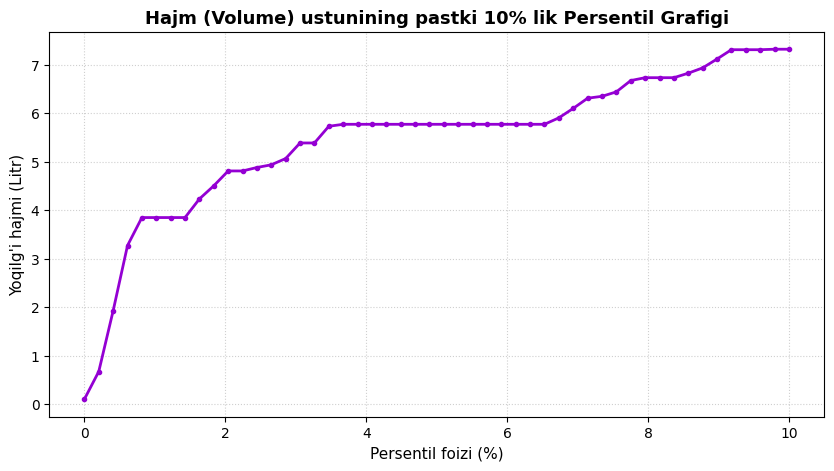

In [90]:
foizlar = np.linspace(0, 10, 50)  
qiymatlar = [df['volume'].quantile(f / 100) for f in foizlar]

plt.figure(figsize=(10, 5))
plt.plot(foizlar, qiymatlar, marker='.', color='darkviolet', linewidth=2)

plt.title("Hajm (Volume) ustunining pastki 10% lik Persentil Grafigi", fontsize=13, fontweight='bold')
plt.xlabel("Persentil foizi (%)", fontsize=11)
plt.ylabel("Yoqilg'i hajmi (Litr)", fontsize=11)
plt.grid(True, linestyle=':', alpha=0.6)


plt.show()

In [91]:
micro_volumes = df[df['volume'] < 3.8]

total_rows = len(df)
micro_rows = len(micro_volumes)
percent = (micro_rows / total_rows) * 100

print(f"Umumiy qatorlar soni: {total_rows}")
print(f"3.8 litrdan kam tranzaksiyalar soni: {micro_rows} ta")
print(percent)


micro_volumes.head(10)

Umumiy qatorlar soni: 316154
3.8 litrdan kam tranzaksiyalar soni: 2441 ta
0.7720920817070163


,local_time,hour,day_of_week,month,dispenser_id,price,volume,amount,branch_id,xizmat_vaqti
178878,2025-02-15 04:44:04.494000+00:00,4,Saturday,February,1,3950.0,1.171,4625.4,1,6.028550
150654,2025-02-15 05:08:35.875000+00:00,5,Saturday,February,1,3950.0,3.020,11929.0,1,3.600017
150684,2025-02-15 16:28:25.540000+00:00,16,Saturday,February,1,3950.0,0.924,3649.8,1,4.643700
178755,2025-02-16 06:29:33.077000+00:00,6,Sunday,February,1,3950.0,2.988,11802.6,1,2.090567
178753,2025-02-16 07:45:24.820000+00:00,7,Sunday,February,1,3950.0,0.204,805.8,1,7.568833
178547,2025-02-16 07:49:05.332000+00:00,7,Sunday,February,1,3950.0,3.690,14575.5,1,3.675200
178708,2025-02-16 08:46:43.083000+00:00,8,Sunday,February,1,3950.0,3.662,14464.9,1,5.955567
178613,2025-02-16 09:20:49.408000+00:00,9,Sunday,February,1,3950.0,3.761,14855.9,1,11.252017
151425,2025-02-17 07:21:43.492000+00:00,7,Monday,February,1,3950.0,0.888,3507.6,1,8.651267
151306,2025-02-17 09:19:17.008000+00:00,9,Monday,February,1,3950.0,0.145,572.7,1,0.587350


In [92]:
df.drop(index=micro_volumes.index, inplace=True)

In [93]:
max_100 = df[df['volume'] > 100]
max_150 = df[df['volume'] > 150]
max_200 = df[df['volume'] > 200]
max_300 = df[df['volume'] > 300]

total_rows = len(df)  

print(f"Umumiy qatorlar soni: {total_rows}\n")
print(f"100 litrdan katta tranzaksiyalar: {len(max_100)} ta ")
print(f"150 litrdan katta tranzaksiyalar: {len(max_150)} ta ")
print(f"200 litrdan katta tranzaksiyalar: {len(max_200)} ta ")
print(f"300 litrdan katta tranzaksiyalar: {len(max_300)} ta ")

df.sort_values(by='volume', ascending=False).head(10)

Umumiy qatorlar soni: 313713

100 litrdan katta tranzaksiyalar: 30 ta 
150 litrdan katta tranzaksiyalar: 7 ta 
200 litrdan katta tranzaksiyalar: 1 ta 
300 litrdan katta tranzaksiyalar: 0 ta 


,local_time,hour,day_of_week,month,dispenser_id,price,volume,amount,branch_id,xizmat_vaqti
151760,2025-02-20 11:23:03.086000+00:00,11,Thursday,February,5,3950.0,212.342,838750.9,1,25.531983
317479,2025-09-06 11:14:24.731000+00:00,11,Saturday,September,9,5200.0,188.462,980000.0,1,26.373600
317099,2025-09-06 09:40:35.130000+00:00,9,Saturday,September,9,5200.0,173.077,900000.0,1,21.462483
54078,2025-05-30 12:34:16.948000+00:00,12,Friday,May,2,5200.0,173.077,900000.0,1,12.983283
317081,2025-09-06 10:24:29.235000+00:00,10,Saturday,September,10,5200.0,173.077,900000.0,1,19.501133
6085,2025-05-16 12:04:14.131000+00:00,12,Friday,May,5,5200.0,172.060,894712.0,1,23.860483
313055,2025-09-05 14:47:44.201000+00:00,14,Friday,September,3,5200.0,162.274,843824.8,1,17.829400
141925,2025-04-29 13:12:05.945000+00:00,13,Tuesday,April,3,4100.0,146.342,600000.0,1,13.573483
150759,2025-02-15 15:30:17.803000+00:00,15,Saturday,February,5,3950.0,138.681,547789.9,1,20.759250
85430,2025-05-01 19:17:30.348000+00:00,19,Thursday,May,7,5200.0,125.000,650000.0,1,14.301700


In [94]:
df.drop(index=max_200.index, inplace=True)

In [95]:
df.shape

(313712, 10)

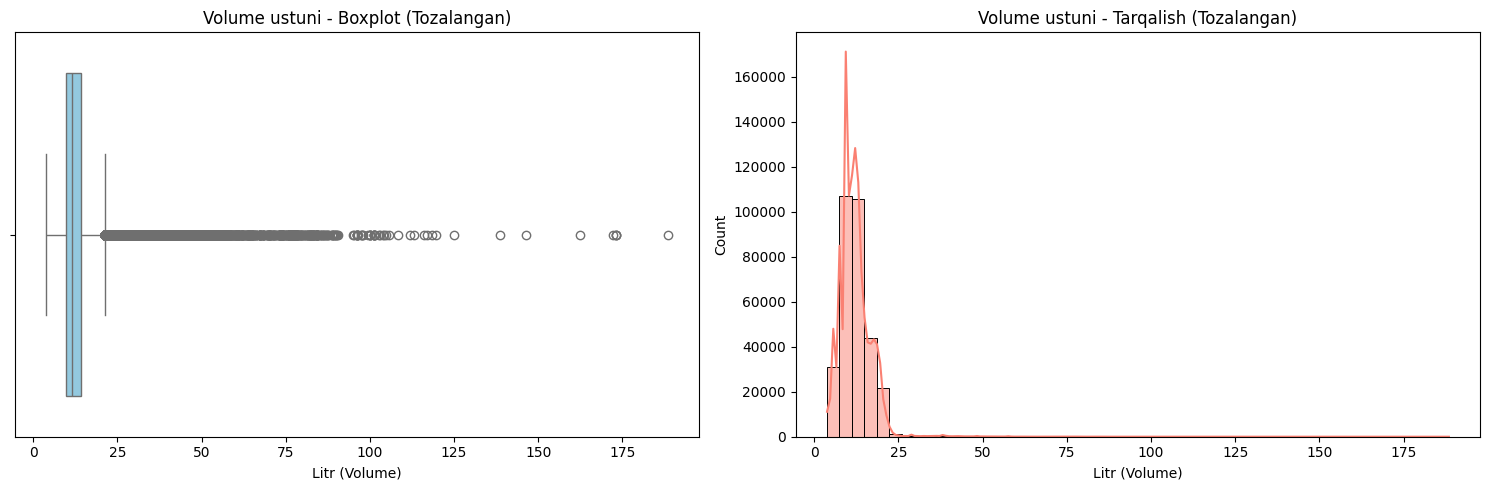

In [96]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(x=df['volume'], ax=axes[0], color='skyblue')
axes[0].set_title("Volume ustuni - Boxplot (Tozalangan)")
axes[0].set_xlabel("Litr (Volume)")

sns.histplot(df['volume'], bins=50, kde=True, ax=axes[1], color='salmon')
axes[1].set_title("Volume ustuni - Tarqalish (Tozalangan)")
axes[1].set_xlabel("Litr (Volume)")

plt.tight_layout()
plt.show()

In [97]:
day_map = {'Monday':0, 'Tuesday':1, 'Wednesday':2, 'Thursday':3, 'Friday':4, 'Saturday':5, 'Sunday':6}
df['day_of_week_encoded'] = df['day_of_week'].map(day_map)

In [98]:
df['date_only'] = df['local_time'].dt.date

In [99]:
hourly_data = df.groupby(['branch_id', 'date_only', 'month', 'day_of_week_encoded', 'hour']).agg(
    mashina_soni=('volume', 'count')
).reset_index()

In [100]:
branch_daily_stats = hourly_data.groupby(['branch_id', 'date_only'])['mashina_soni'].agg(['max', 'min']).reset_index()
branch_daily_stats.columns = ['branch_id', 'date_only', 'daily_max_soni', 'daily_min_soni']

hourly_data = pd.merge(hourly_data, branch_daily_stats, on=['branch_id', 'date_only'], how='left')

hourly_data['target_usul_1'] = hourly_data['mashina_soni'] / hourly_data['daily_max_soni']

hourly_data['target_usul_2'] = (hourly_data['mashina_soni'] - hourly_data['daily_min_soni']) / (hourly_data['daily_max_soni'] - hourly_data['daily_min_soni'] + 1e-5)

In [101]:
hourly_data['datetime_full'] = pd.to_datetime(hourly_data['date_only'].astype(str)) + pd.to_timedelta(hourly_data['hour'], unit='h')

malumot1 = hourly_data[['branch_id', 'datetime_full', 'target_usul_1']].copy()
malumot2 = hourly_data[['branch_id', 'datetime_full', 'target_usul_2']].copy()

#--- TARGET 1

# 1 kun oldin 
malumot1_1kun = malumot1.copy()
malumot1_1kun['datetime_full'] = malumot1_1kun['datetime_full'] + pd.Timedelta(days=1)
malumot1_1kun = malumot1_1kun.rename(columns={'target_usul_1': 'bir_kun_oldin_usul_1'})

# 2 kun oldin 
malumot1_2kun = malumot1.copy()
malumot1_2kun['datetime_full'] = malumot1_2kun['datetime_full'] + pd.Timedelta(days=2)
malumot1_2kun = malumot1_2kun.rename(columns={'target_usul_1': 'ikki_kun_oldin_usul_1'})

# 3 kun oldin 
malumot1_3kun = malumot1.copy()
malumot1_3kun['datetime_full'] = malumot1_3kun['datetime_full'] + pd.Timedelta(days=3)
malumot1_3kun = malumot1_3kun.rename(columns={'target_usul_1': 'uch_kun_oldin_usul_1'})

# 1 hafta oldin 
malumot1_1hafta = malumot1.copy()
malumot1_1hafta['datetime_full'] = malumot1_1hafta['datetime_full'] + pd.Timedelta(days=7)
malumot1_1hafta = malumot1_1hafta.rename(columns={'target_usul_1': 'bir_hafta_oldin_usul_1'})


# --- TARGET 2

# 1 kun oldin
malumot2_1kun = malumot2.copy()
malumot2_1kun['datetime_full'] = malumot2_1kun['datetime_full'] + pd.Timedelta(days=1)
malumot2_1kun = malumot2_1kun.rename(columns={'target_usul_2': 'bir_kun_oldin_usul_2'})

# 2 kun oldin
malumot2_2kun = malumot2.copy()
malumot2_2kun['datetime_full'] = malumot2_2kun['datetime_full'] + pd.Timedelta(days=2)
malumot2_2kun = malumot2_2kun.rename(columns={'target_usul_2': 'ikki_kun_oldin_usul_2'})

# 3 kun oldin
malumot2_3kun = malumot2.copy()
malumot2_3kun['datetime_full'] = malumot2_3kun['datetime_full'] + pd.Timedelta(days=3)
malumot2_3kun = mal_col = malumot2.copy()
malumot2_3kun['datetime_full'] = malumot2_3kun['datetime_full'] + pd.Timedelta(days=3)
malumot2_3kun = malumot2_3kun.rename(columns={'target_usul_2': 'uch_kun_oldin_usul_2'})

# 1 hafta oldin
malumot2_1hafta = malumot2.copy()
malumot2_1hafta['datetime_full'] = malumot2_1hafta['datetime_full'] + pd.Timedelta(days=7)
malumot2_1hafta = malumot2_1hafta.rename(columns={'target_usul_2': 'bir_hafta_oldin_usul_2'})


# Merging

# Target 1 
hourly_data = hourly_data.merge(malumot1_1kun, on=['branch_id', 'datetime_full'], how='left')
hourly_data = hourly_data.merge(malumot1_2kun, on=['branch_id', 'datetime_full'], how='left')
hourly_data = hourly_data.merge(malumot1_3kun, on=['branch_id', 'datetime_full'], how='left')
hourly_data = hourly_data.merge(malumot1_1hafta, on=['branch_id', 'datetime_full'], how='left')

# Target 2
hourly_data = hourly_data.merge(malumot2_1kun, on=['branch_id', 'datetime_full'], how='left')
hourly_data = hourly_data.merge(malumot2_2kun, on=['branch_id', 'datetime_full'], how='left')
hourly_data = hourly_data.merge(malumot2_3kun, on=['branch_id', 'datetime_full'], how='left')
hourly_data = hourly_data.merge(malumot2_1hafta, on=['branch_id', 'datetime_full'], how='left')

# NaN qiymatlarni to'dirish

lag_columns = [
    'bir_kun_oldin_usul_1', 'ikki_kun_oldin_usul_1', 'uch_kun_oldin_usul_1', 'bir_hafta_oldin_usul_1',
    'bir_kun_oldin_usul_2', 'ikki_kun_oldin_usul_2', 'uch_kun_oldin_usul_2', 'bir_hafta_oldin_usul_2'
]

hourly_data = hourly_data.sort_values(by=['branch_id', 'datetime_full']).reset_index(drop=True)

for col in lag_columns:
    hourly_data[col] = hourly_data.groupby('branch_id')[col].bfill().ffill()

In [102]:
hourly_data = hourly_data.sort_values(['branch_id', 'hour', 'datetime_full']).reset_index(drop=True)

# TARGET 1 
hourly_data['oxirgi_7kun_ortacha_usul_1'] = (
    hourly_data.groupby(['branch_id', 'hour'])['target_usul_1']
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
)
hourly_data['oxirgi_7kun_ortacha_usul_1'] = hourly_data['oxirgi_7kun_ortacha_usul_1'].ffill().bfill()


# TARGET 2 
hourly_data['oxirgi_7kun_ortacha_usul_2'] = (
    hourly_data.groupby(['branch_id', 'hour'])['target_usul_2']
    .transform(lambda x: x.shift(1).rolling(window=7, min_periods=1).mean())
)
hourly_data['oxirgi_7kun_ortacha_usul_2'] = hourly_data['oxirgi_7kun_ortacha_usul_2'].ffill().bfill()


hourly_data = hourly_data.sort_values(['branch_id', 'datetime_full']).reset_index(drop=True)

In [103]:
dataset_solishtirish = hourly_data[[
    'branch_id', 'month', 'day_of_week_encoded', 'hour', 'mashina_soni', 
    'target_usul_1', 
    'target_usul_2',  
    # Target 1 uchun 
    'bir_kun_oldin_usul_1', 
    'ikki_kun_oldin_usul_1',
    'uch_kun_oldin_usul_1',
    'bir_hafta_oldin_usul_1',
    'oxirgi_7kun_ortacha_usul_1',
    # Target 2 uchun 
    'bir_kun_oldin_usul_2', 
    'ikki_kun_oldin_usul_2',
    'uch_kun_oldin_usul_2',
    'bir_hafta_oldin_usul_2',
    'oxirgi_7kun_ortacha_usul_2'
]]

In [104]:
dataset_solishtirish

,branch_id,month,day_of_week_encoded,hour,mashina_soni,target_usul_1,target_usul_2,bir_kun_oldin_usul_1,ikki_kun_oldin_usul_1,uch_kun_oldin_usul_1,bir_hafta_oldin_usul_1,oxirgi_7kun_ortacha_usul_1,bir_kun_oldin_usul_2,ikki_kun_oldin_usul_2,uch_kun_oldin_usul_2,bir_hafta_oldin_usul_2,oxirgi_7kun_ortacha_usul_2
0,1,February,2,12,4,1.000000,0.000000,0.100000,1.000000,1.000000,1.000000,0.852026,0.000000,0.00,0.000000,0.000000,0.834232
1,1,February,3,14,1,1.000000,0.000000,0.100000,1.000000,1.000000,1.000000,0.806197,0.000000,0.00,0.000000,0.000000,0.789577
2,1,February,4,7,1,0.100000,0.000000,0.100000,1.000000,1.000000,1.000000,0.563082,0.000000,0.00,0.000000,0.000000,0.523378
3,1,February,4,15,10,1.000000,0.999999,0.100000,1.000000,1.000000,1.000000,0.606974,0.000000,0.00,0.000000,0.000000,0.581717
4,1,February,4,16,1,0.100000,0.000000,0.100000,1.000000,1.000000,1.000000,0.695132,0.000000,0.00,0.000000,0.000000,0.668106
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3763,1,September,4,8,97,0.836207,0.831858,0.905983,0.819549,0.881356,0.635897,0.821561,0.902655,0.76,0.866667,0.634021,0.807816
3764,1,September,4,9,116,1.000000,1.000000,1.000000,1.000000,1.000000,0.902564,0.961609,1.000000,1.00,1.000000,0.902062,0.960669
3765,1,September,4,10,110,0.948276,0.946903,0.923077,0.721805,0.932203,1.000000,0.910470,0.920354,0.63,0.923809,1.000000,0.895277
3766,1,September,4,11,85,0.732759,0.725664,0.675214,0.721805,0.906780,0.969231,0.852026,0.663717,0.63,0.895238,0.969072,0.834232


In [105]:
dataset = dataset_solishtirish.copy()

In [106]:
month_map = {
    'January': 1, 'February': 2, 'March': 3, 'April': 4, 'May': 5, 'June': 6,
    'July': 7, 'August': 8, 'September': 9, 'October': 10, 'November': 11, 'December': 12
}
dataset['month_encoded'] = dataset['month'].map(month_map)

In [107]:
dataset

,branch_id,month,day_of_week_encoded,hour,mashina_soni,target_usul_1,target_usul_2,bir_kun_oldin_usul_1,ikki_kun_oldin_usul_1,uch_kun_oldin_usul_1,bir_hafta_oldin_usul_1,oxirgi_7kun_ortacha_usul_1,bir_kun_oldin_usul_2,ikki_kun_oldin_usul_2,uch_kun_oldin_usul_2,bir_hafta_oldin_usul_2,oxirgi_7kun_ortacha_usul_2,month_encoded
0,1,February,2,12,4,1.000000,0.000000,0.100000,1.000000,1.000000,1.000000,0.852026,0.000000,0.00,0.000000,0.000000,0.834232,2
1,1,February,3,14,1,1.000000,0.000000,0.100000,1.000000,1.000000,1.000000,0.806197,0.000000,0.00,0.000000,0.000000,0.789577,2
2,1,February,4,7,1,0.100000,0.000000,0.100000,1.000000,1.000000,1.000000,0.563082,0.000000,0.00,0.000000,0.000000,0.523378,2
3,1,February,4,15,10,1.000000,0.999999,0.100000,1.000000,1.000000,1.000000,0.606974,0.000000,0.00,0.000000,0.000000,0.581717,2
4,1,February,4,16,1,0.100000,0.000000,0.100000,1.000000,1.000000,1.000000,0.695132,0.000000,0.00,0.000000,0.000000,0.668106,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3763,1,September,4,8,97,0.836207,0.831858,0.905983,0.819549,0.881356,0.635897,0.821561,0.902655,0.76,0.866667,0.634021,0.807816,9
3764,1,September,4,9,116,1.000000,1.000000,1.000000,1.000000,1.000000,0.902564,0.961609,1.000000,1.00,1.000000,0.902062,0.960669,9
3765,1,September,4,10,110,0.948276,0.946903,0.923077,0.721805,0.932203,1.000000,0.910470,0.920354,0.63,0.923809,1.000000,0.895277,9
3766,1,September,4,11,85,0.732759,0.725664,0.675214,0.721805,0.906780,0.969231,0.852026,0.663717,0.63,0.895238,0.969072,0.834232,9


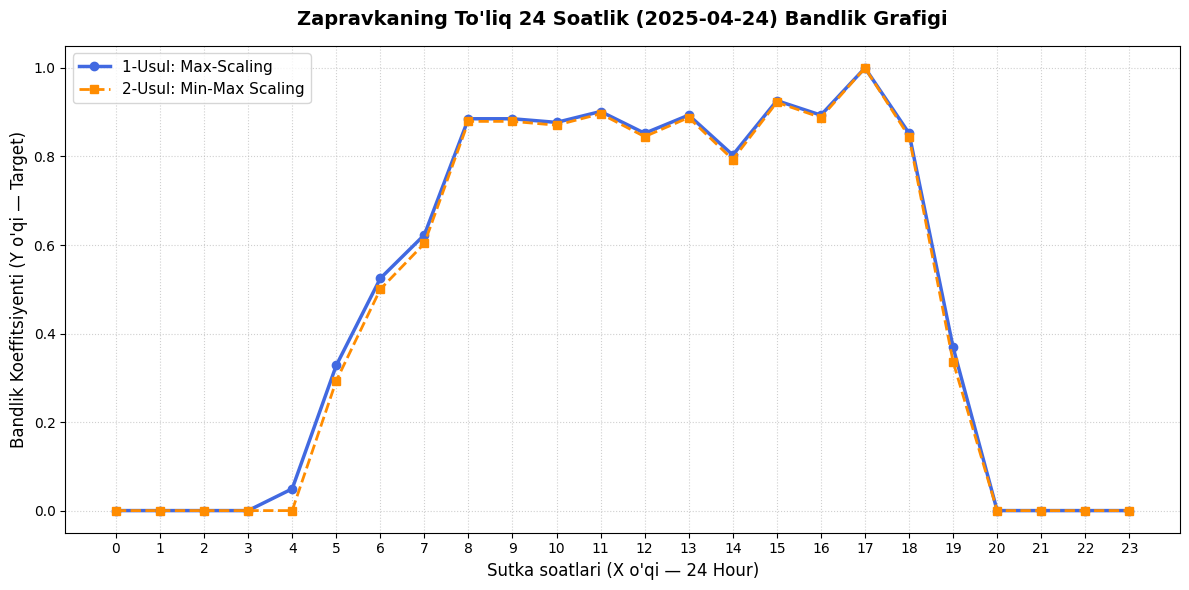

In [108]:
aniq_sana = pd.to_datetime('2025-04-24').date()


namuna_kun = dataset_solishtirish[hourly_data['date_only'] == aniq_sana].sort_values(by='hour').reset_index(drop=True)

to_liq_soatlar = pd.DataFrame({'hour': range(0, 24)})

namuna_kun = pd.merge(to_liq_soatlar, namuna_kun, on='hour', how='left')

namuna_kun['target_usul_1'] = namuna_kun['target_usul_1'].fillna(0.0)
namuna_kun['target_usul_2'] = namuna_kun['target_usul_2'].fillna(0.0)


plt.figure(figsize=(12, 6))

plt.plot(namuna_kun['hour'], namuna_kun['target_usul_1'], 
         marker='o', linestyle='-', linewidth=2.5, color='royalblue', 
         label="1-Usul: Max-Scaling")

plt.plot(namuna_kun['hour'], namuna_kun['target_usul_2'], 
         marker='s', linestyle='--', linewidth=2, color='darkorange', 
         label="2-Usul: Min-Max Scaling")

plt.title(f"Zapravkaning To'liq 24 Soatlik ({aniq_sana}) Bandlik Grafigi", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Sutka soatlari (X o'qi — 24 Hour)", fontsize=12)
plt.ylabel("Bandlik Koeffitsiyenti (Y o'qi — Target)", fontsize=12)

plt.xticks(range(0, 24))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(fontsize=11, loc='upper left')

plt.tight_layout()
plt.show()

In [109]:
X1_cols = [
    'month_encoded', 'day_of_week_encoded', 'hour', 
    'bir_kun_oldin_usul_1', 'ikki_kun_oldin_usul_1', 
    'uch_kun_oldin_usul_1', 'bir_hafta_oldin_usul_1', 
]

X1 = dataset[X1_cols]
y_1 = dataset['target_usul_1']


X2_cols = [
    'month_encoded', 'day_of_week_encoded', 'hour', 
    'bir_kun_oldin_usul_2', 'ikki_kun_oldin_usul_2', 
    'uch_kun_oldin_usul_2', 'bir_hafta_oldin_usul_2', 
]

X2 = dataset[X2_cols]
y_2 = dataset['target_usul_2']

In [110]:
barcha_sanalar = sorted(hourly_data['date_only'].unique())
kesim_indeks = int(len(barcha_sanalar) * 0.8) 
kesim_sana = barcha_sanalar[kesim_indeks]
print("Kesim sanasi:", kesim_sana)

Kesim sanasi: 2025-08-02


In [111]:
kesim_sana = pd.to_datetime('2025-08-02').date()
train_mask = hourly_data['date_only'] < kesim_sana
test_mask = hourly_data['date_only'] >= kesim_sana

X1_train, X1_test = X1[train_mask], X1[test_mask]
y1_train, y1_test = y_1[train_mask], y_1[test_mask]

X2_train, X2_test = X2[train_mask], X2[test_mask]
y2_train, y2_test = y_2[train_mask], y_2[test_mask]

In [112]:
print("X1_train:", X1_train.shape)
print("X1_test:", X1_test.shape)
print("X2_train:", X2_train.shape)
print("X2_test:", X2_test.shape)

X1_train: (2974, 7)
X1_test: (794, 7)
X2_train: (2974, 7)
X2_test: (794, 7)


In [113]:
from sklearn.model_selection import GridSearchCV
from catboost import CatBoostRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import time

In [ ]:
t0 = time.time()

cat_grid_kichik = {
    'depth': [4, 6, 8],
    'learning_rate': [0.05, 0.1],
    'iterations': [200, 300]
}

cat_search = GridSearchCV(
    CatBoostRegressor(random_seed=42, verbose=False),
    cat_grid_kichik,
    cv=3,
    scoring='r2',
    n_jobs=-1
)
cat_search.fit(X2_train, y2_train)

print("=== CATBOOST ===")
print("Eng yaxshi parametrlar:", cat_search.best_params_)
print("Eng yaxshi CV R²:", cat_search.best_score_)
print(f"Vaqt: {time.time()-t0:.1f} soniya")

In [ ]:
cat_features = ['day_of_week_encoded']

# Target 1
cat_model_1 = CatBoostRegressor(iterations=78, depth=6, learning_rate=0.1, random_seed=42, verbose=False)
cat_model_1.fit(X1_train, y1_train, cat_features=cat_features)

rf_model_1 = RandomForestRegressor(n_estimators=400, max_depth=6, random_state=42)
rf_model_1.fit(X1_train, y1_train)

xgb_model_1 = XGBRegressor(n_estimators=80, max_depth=3, learning_rate=0.1, random_state=42)
xgb_model_1.fit(X1_train, y1_train)

In [ ]:
# Target 2
cat_model_2 = CatBoostRegressor(iterations=91, depth=6, learning_rate=0.1, random_seed=42, verbose=False)
cat_model_2.fit(X2_train, y2_train, cat_features=cat_features)

rf_model_2 = RandomForestRegressor(n_estimators=400, max_depth=6, random_state=42)
rf_model_2.fit(X2_train, y2_train)

xgb_model_2 = XGBRegressor(n_estimators=98, max_depth=3, learning_rate=0.1, random_state=42)
xgb_model_2.fit(X2_train, y2_train)

In [ ]:
cat_preds_1 = cat_model_1.predict(X1_test)
rf_preds_1 = rf_model_1.predict(X1_test)
xgb_preds_1 = xgb_model_1.predict(X1_test)

natijalar_1 = {}
for name, preds in [('CatBoost', cat_preds_1), ('RandomForest', rf_preds_1), ('XGBoost', xgb_preds_1)]:
    mae = mean_absolute_error(y1_test, preds)
    rmse = np.sqrt(mean_squared_error(y1_test, preds))
    r2 = r2_score(y1_test, preds)
    natijalar_1[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

natijalar_1_df = pd.DataFrame(natijalar_1).T
natijalar_1_df

In [ ]:
cat_preds_2 = cat_model_2.predict(X2_test)
rf_preds_2 = rf_model_2.predict(X2_test)
xgb_preds_2 = xgb_model_2.predict(X2_test)

natijalar_2 = {}
for name, preds in [('CatBoost', cat_preds_2), ('RandomForest', rf_preds_2), ('XGBoost', xgb_preds_2)]:
    mae = mean_absolute_error(y2_test, preds)
    rmse = np.sqrt(mean_squared_error(y2_test, preds))
    r2 = r2_score(y2_test, preds)
    natijalar_2[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}

natijalar_2_df = pd.DataFrame(natijalar_2).T
natijalar_2_df

In [ ]:
# Target 1
for name, model in [('CatBoost', cat_model_1), ('RandomForest', rf_model_1), ('XGBoost', xgb_model_1)]:
    train_preds = model.predict(X1_train)
    test_preds = model.predict(X1_test)
    train_r1 = r2_score(y1_train, train_preds)
    test_r1 = r2_score(y1_test, test_preds)
    print(f"{name}: Train R²={train_r1:.4f}, Test R²={test_r1:.4f}, Farq={train_r1-test_r1:.4f}")

In [ ]:
# Target 2
for name, model in [('CatBoost', cat_model_2), ('RandomForest', rf_model_2), ('XGBoost', xgb_model_2)]:
    train_preds = model.predict(X2_train)
    test_preds = model.predict(X2_test)
    train_r2 = r2_score(y2_train, train_preds)
    test_r2 = r2_score(y2_test, test_preds)
    print(f"{name}: Train R²={train_r2:.4f}, Test R²={test_r2:.4f}, Farq={train_r2-test_r2:.4f}")

In [ ]:
# # Oxirgi 7 kunlik o'rtacha

baseline_preds_1 = dataset.loc[X1_test.index, 'oxirgi_7kun_ortacha_usul_1']

b1_mae = mean_absolute_error(y1_test, baseline_preds_1)
b1_rmse = np.sqrt(mean_squared_error(y1_test, baseline_preds_1))
b1_r2 = r2_score(y1_test, baseline_preds_1)


baseline_preds_2 = dataset.loc[X2_test.index, 'oxirgi_7kun_ortacha_usul_2']

b2_mae = mean_absolute_error(y2_test, baseline_preds_2)
b2_rmse = np.sqrt(mean_squared_error(y2_test, baseline_preds_2))
b2_r2 = r2_score(y2_test, baseline_preds_2)


print("-*-*- TARGET 1 BASELINE (7 kunlik o'rtacha) -*-*-")
print("MAE  :", round(b1_mae, 4))
print("RMSE :", round(b1_rmse, 4))
print("R2   :", round(b1_r2, 4))

print("\n-*-*- TARGET 2 BASELINE (7 kunlik o'rtacha) -*-*-")
print("MAE  :", round(b2_mae, 4))
print("RMSE :", round(b2_rmse, 4))
print("R2   :", round(b2_r2, 4))

In [ ]:
importances = rf_model_1.feature_importances_

feature_names = X1_train.columns
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True) 

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.3, 0.8, len(feature_imp_df)))

plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'], color=colors, edgecolor='black')
plt.xlabel('Muhimlik darajasi (Importance Score)', fontsize=12)
plt.ylabel('Featurelar (Ustunlar)', fontsize=12)
plt.title('Random Forest - Feature Importance', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for index, value in enumerate(feature_imp_df['Importance']):
    plt.text(value + 0.005, index, f'{value:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
importances = rf_model_2.feature_importances_

feature_names = X2_train.columns
feature_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=True) 

plt.figure(figsize=(10, 6))
colors = plt.cm.viridis(np.linspace(0.3, 0.8, len(feature_imp_df)))

plt.barh(feature_imp_df['Feature'], feature_imp_df['Importance'], color=colors, edgecolor='black')
plt.xlabel('Muhimlik darajasi (Importance Score)', fontsize=12)
plt.ylabel('Featurelar (Ustunlar)', fontsize=12)
plt.title('Random Forest - Feature Importance', fontsize=14, fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for index, value in enumerate(feature_imp_df['Importance']):
    plt.text(value + 0.005, index, f'{value:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 12))

modellar = [('CatBoost', cat_preds_2), ('RandomForest', rf_preds_2), ('XGBoost', xgb_preds_2)]

for i, (name, preds) in enumerate(modellar):
    axes[i].plot(y2_test.values[:100], label='Haqiqiy', marker='o')
    axes[i].plot(preds[:100], label=f'Bashorat ({name})', marker='x')
    axes[i].legend()
    axes[i].set_title(f'Haqiqiy vs Bashorat - {name}')
    axes[i].set_ylabel('Bandlik darajasi')

axes[2].set_xlabel('Test namunasi')
plt.tight_layout()
plt.show()